# Modelo 1: BiLSTM + CRF + FastText para NER (Kaggle)

**Objetivo**: Mejorar el baseline (64.3% F1) usando:
- ✅ **Embeddings FastText** preentrenados en español (300d)
- ✅ **CRF Layer** para coherencia en secuencias de etiquetas
- ✅ **BiLSTM** bidireccional (2 capas)

**Dataset**: CoNLL-2002 Spanish NER
- **Entidades**: PER, LOC, ORG, MISC
- **Esquema**: BIO tagging
- **Total**: 11,755 oraciones, 26,706 entidades

**Arquitectura**:
```
Input → FastText Embeddings (300d, frozen) → Dropout(0.3) →
BiLSTM(256) × 2 capas → Dropout(0.3) → Linear(512 → num_tags) → CRF → Output
```

**Requisitos Kaggle**:
1. GPU T4 x2 activada
2. Dataset CoNLL-2002 agregado
3. Internet ON (para descargar FastText)

## 1. Instalación de Dependencias

In [43]:
# ===================================================================
# IMPORTANTE: Ejecuta esta celda PRIMERO y espera a que termine
# Luego ejecuta las siguientes celdas
# ===================================================================

import subprocess
import sys

print("="*70)
print("INSTALANDO DEPENDENCIAS PARA BILSTM + CRF + FASTTEXT")
print("="*70)

# Instalar paquetes uno por uno con verificación
packages = {
    'seqeval': 'seqeval',
    'torchcrf': 'torchcrf', 
    'gensim': 'gensim'
}

for name, package in packages.items():
    print(f"\n📦 Instalando {name}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {name} instalado")
    except Exception as e:
        print(f"❌ Error: {e}")

# Verificar instalaciones
print("\n" + "="*70)
print("VERIFICANDO INSTALACIÓN")
print("="*70)

success = True

try:
    import seqeval
    from seqeval.metrics import f1_score
    print("✅ seqeval disponible")
except ImportError as e:
    print(f"❌ seqeval: {e}")
    success = False

try:
    from torchcrf import CRF
    print("✅ torchcrf disponible")
except ImportError as e:
    print(f"❌ torchcrf: {e}")
    print("⚠️  Instalando alternativa pytorch-crf...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pytorch-crf"])
        from TorchCRF import CRF
        print("✅ pytorch-crf instalado")
    except:
        print("❌ Ambas opciones de CRF fallaron")
        success = False

try:
    import gensim
    import gensim.downloader as api
    print("✅ gensim disponible")
except ImportError as e:
    print(f"❌ gensim: {e}")
    success = False

print("\n" + "="*70)
if success:
    print("✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE")
    print("✅ Continúa ejecutando las siguientes celdas")
else:
    print("❌ HUBO ERRORES EN LA INSTALACIÓN")
    print("⚠️  Reporta los mensajes de error arriba")
print("="*70)

INSTALANDO DEPENDENCIAS PARA BILSTM + CRF + FASTTEXT

📦 Instalando seqeval...
✅ seqeval instalado

📦 Instalando torchcrf...
✅ torchcrf instalado

📦 Instalando gensim...
✅ gensim instalado

VERIFICANDO INSTALACIÓN
✅ seqeval disponible
✅ torchcrf disponible
✅ gensim disponible

✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE
✅ Continúa ejecutando las siguientes celdas


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchcrf import CRF

import numpy as np
import pandas as pd
import json
from pathlib import Path
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
import time

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from seqeval.scheme import IOB2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('\n✅ Librerías cargadas correctamente')
print('✅ Listo para continuar con el entrenamiento')

Device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4
GPU Memory: 15.64 GB

✅ Librerías cargadas correctamente
✅ Listo para continuar con el entrenamiento


## 2. Imports y Configuración

**Ejecuta esta celda DESPUÉS de verificar que la instalación fue exitosa (✅ arriba).**

## 3. Configuración de Rutas y Parámetros

In [45]:
# Rutas KAGGLE
DATA_DIR = Path('/kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner')
OUTPUT_DIR = Path('/kaggle/working')

TRAIN_FILE = DATA_DIR / 'train.txt'
VALID_FILE = DATA_DIR / 'valid.txt'
TEST_FILE = DATA_DIR / 'test.txt'

print(f'Dataset directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'\nArchivos disponibles:')
print(f'  Train: {TRAIN_FILE.exists()}')
print(f'  Valid: {VALID_FILE.exists()}')
print(f'  Test: {TEST_FILE.exists()}')

if not TRAIN_FILE.exists():
    print(f'\n⚠️ Dataset no encontrado. Contenido de {DATA_DIR}:')
    if DATA_DIR.exists():
        for item in DATA_DIR.iterdir():
            print(f'  - {item.name}')

# Hiperparámetros
CONFIG = {
    'model_name': 'BiLSTM_CRF_FastText',
    'max_length': 62,
    'embedding_dim': 300,  # FastText español
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.3,
    'batch_size': 64,
    'learning_rate': 0.001,
    'num_epochs': 25,
    'patience': 5,
    'grad_clip': 5.0,
    'freeze_embeddings': True  # No entrenar FastText
}

print('\nConfiguración:')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

Dataset directory: /kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner
Output directory: /kaggle/working

Archivos disponibles:
  Train: True
  Valid: True
  Test: True

Configuración:
  model_name: BiLSTM_CRF_FastText
  max_length: 62
  embedding_dim: 300
  hidden_dim: 256
  num_layers: 2
  dropout: 0.3
  batch_size: 64
  learning_rate: 0.001
  num_epochs: 25
  patience: 5
  grad_clip: 5.0
  freeze_embeddings: True


## 3. Descargar FastText Español

Usaremos los embeddings preentrenados en español de FastText (300 dimensiones).

In [46]:
print('Descargando FastText español (esto puede tardar ~5 minutos)...')
print('Tamaño: ~9.5 GB comprimido, ~1M palabras en español')

# Descargar usando gensim
# Alternativa: fasttext-wiki-news-subwords-300 (multilingüe)
# Para español puro: usar el modelo de Facebook FastText

# Opción 1: Fasttext multilingüe (más rápido de descargar)
print('\nDescargando fasttext-wiki-news-subwords-300...')
fasttext_model = api.load('fasttext-wiki-news-subwords-300')

print(f'\n✅ FastText cargado')
print(f'Vocabulario: {len(fasttext_model):,} palabras')
print(f'Dimensión: {fasttext_model.vector_size}d')

# Test
test_words = ['madrid', 'españa', 'garcía', 'empresa']
print(f'\nTest embeddings:')
for word in test_words:
    if word in fasttext_model:
        print(f'  ✅ {word}: {fasttext_model[word][:5]}...')
    else:
        print(f'  ⚠️ {word}: OOV')

Descargando FastText español (esto puede tardar ~5 minutos)...
Tamaño: ~9.5 GB comprimido, ~1M palabras en español

Descargando fasttext-wiki-news-subwords-300...

✅ FastText cargado
Vocabulario: 999,999 palabras
Dimensión: 300d

Test embeddings:
  ✅ madrid: [ 0.079255 -0.041383 -0.086874 -0.04513   0.056038]...
  ✅ españa: [ 0.040857  -0.073434  -0.071831  -0.028046  -0.0028862]...
  ⚠️ garcía: OOV
  ✅ empresa: [ 0.0058872 -0.018694  -0.047298   0.012623  -0.014585 ]...


## 4. Carga y Procesamiento de Datos

In [47]:
def load_conll_file(filepath):
    """Carga archivo CoNLL formato: palabra POS etiqueta_NER"""
    sentences = []
    words, tags = [], []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 3:
                    word, _, ner_tag = parts[0], parts[1], parts[2]
                    words.append(word.lower())
                    tags.append(ner_tag)
    
    if words:
        sentences.append((words, tags))
    
    return sentences

print('Cargando datos...')
train_data = load_conll_file(TRAIN_FILE)
valid_data = load_conll_file(VALID_FILE)
test_data = load_conll_file(TEST_FILE)

print(f'Train: {len(train_data):,} oraciones')
print(f'Valid: {len(valid_data):,} oraciones')
print(f'Test: {len(test_data):,} oraciones')

Cargando datos...
Train: 8,323 oraciones
Valid: 1,915 oraciones
Test: 1,517 oraciones


## 5. Construcción de Vocabularios

In [48]:
# Construir vocabulario de palabras del dataset
word_counter = Counter()
for words, _ in train_data:
    word_counter.update(words)

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Crear vocabulario (todas las palabras del train)
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in word_counter.keys():
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

# Construir vocabulario de etiquetas NER
tag_set = set()
for _, tags in train_data:
    tag_set.update(tags)

# CRF necesita PAD en índice 0
tag2idx = {'<PAD>': 0}
for tag in sorted(tag_set):
    tag2idx[tag] = len(tag2idx)

idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print(f'\nVocabulario de palabras: {len(word2idx):,} tokens')
print(f'Vocabulario de etiquetas: {len(tag2idx)} tags')
print(f'\nEtiquetas NER: {sorted([t for t in tag2idx.keys() if t != "<PAD>"])}')

# Guardar vocabularios
vocab_info = {
    'word2idx': word2idx,
    'tag2idx': tag2idx,
    'idx2tag': idx2tag,
    'vocab_size': len(word2idx),
    'num_tags': len(tag2idx)
}

with open(OUTPUT_DIR / 'bilstm_crf_fasttext_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_info, f, indent=2, ensure_ascii=False)

print(f'\n✅ Vocabulario guardado')


Vocabulario de palabras: 23,712 tokens
Vocabulario de etiquetas: 10 tags

Etiquetas NER: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

✅ Vocabulario guardado


## 6. Crear Matriz de Embeddings FastText

In [49]:
print('Creando matriz de embeddings desde FastText...')

embedding_dim = CONFIG['embedding_dim']
vocab_size = len(word2idx)

# Inicializar matriz
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

# PAD = vector cero
# UNK = vector aleatorio
embedding_matrix[1] = np.random.normal(0, 0.1, embedding_dim)

found = 0
for word, idx in tqdm(word2idx.items(), desc='Cargando embeddings'):
    if word in [PAD_TOKEN, UNK_TOKEN]:
        continue
    
    if word in fasttext_model:
        embedding_matrix[idx] = fasttext_model[word]
        found += 1
    else:
        # OOV: inicialización aleatoria pequeña
        embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)

coverage = (found / (vocab_size - 2)) * 100
print(f'\n✅ Embeddings creados')
print(f'Palabras encontradas en FastText: {found:,}/{vocab_size-2:,} ({coverage:.2f}%)')
print(f'Matriz shape: {embedding_matrix.shape}')

Creando matriz de embeddings desde FastText...


Cargando embeddings:   0%|          | 0/23712 [00:00<?, ?it/s]


✅ Embeddings creados
Palabras encontradas en FastText: 8,626/23,710 (36.38%)
Matriz shape: (23712, 300)


## 7. Dataset PyTorch

In [50]:
class NERDataset(Dataset):
    def __init__(self, data, word2idx, tag2idx, max_length):
        self.data = data
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.max_length = max_length
        self.unk_idx = word2idx.get(UNK_TOKEN, 1)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        words, tags = self.data[idx]
        
        if len(words) > self.max_length:
            words = words[:self.max_length]
            tags = tags[:self.max_length]
        
        word_ids = [self.word2idx.get(w, self.unk_idx) for w in words]
        tag_ids = [self.tag2idx[t] for t in tags]
        
        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'tag_ids': torch.tensor(tag_ids, dtype=torch.long),
            'length': len(words)
        }

def collate_fn(batch):
    word_ids = [item['word_ids'] for item in batch]
    tag_ids = [item['tag_ids'] for item in batch]
    lengths = [item['length'] for item in batch]
    
    word_ids_padded = pad_sequence(word_ids, batch_first=True, padding_value=0)
    tag_ids_padded = pad_sequence(tag_ids, batch_first=True, padding_value=0)
    
    return {
        'word_ids': word_ids_padded,
        'tag_ids': tag_ids_padded,
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }

train_dataset = NERDataset(train_data, word2idx, tag2idx, CONFIG['max_length'])
valid_dataset = NERDataset(valid_data, word2idx, tag2idx, CONFIG['max_length'])
test_dataset = NERDataset(test_data, word2idx, tag2idx, CONFIG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], 
                         shuffle=False, collate_fn=collate_fn)

print(f'Datasets creados:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Valid batches: {len(valid_loader)}')
print(f'  Test batches: {len(test_loader)}')

Datasets creados:
  Train batches: 131
  Valid batches: 30
  Test batches: 24


## 8. Modelo BiLSTM + CRF + FastText

In [51]:
class BiLSTM_CRF_FastText(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, num_tags, dropout, freeze_emb=True):
        super(BiLSTM_CRF_FastText, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        # Embeddings FastText preentrenados
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=freeze_emb,
            padding_idx=0
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # BiLSTM
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Proyección a tags
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)
        
        # CRF Layer
        self.crf = CRF(num_tags, batch_first=True)
    
    def forward(self, word_ids, tags=None, mask=None):
        # Embeddings
        embedded = self.embedding(word_ids)
        embedded = self.dropout(embedded)
        
        # BiLSTM
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(lstm_out)
        
        # Emisiones (scores para cada tag)
        emissions = self.hidden2tag(lstm_out)
        
        if tags is not None:
            # Training: calcular loss negativo log-likelihood
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return loss
        else:
            # Inference: decodificar secuencia óptima con Viterbi
            predictions = self.crf.decode(emissions, mask=mask)
            return predictions

# Crear modelo
model = BiLSTM_CRF_FastText(
    embedding_matrix=embedding_matrix,
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    num_tags=len(tag2idx),
    dropout=CONFIG['dropout'],
    freeze_emb=CONFIG['freeze_embeddings']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nModelo BiLSTM + CRF + FastText creado:')
print(f'  Total parámetros: {total_params:,}')
print(f'  Parámetros entrenables: {trainable_params:,}')
print(f'  Embeddings congelados: {CONFIG["freeze_embeddings"]}')
print(f'\nArquitectura:')
print(model)


Modelo BiLSTM + CRF + FastText creado:
  Total parámetros: 9,838,594
  Parámetros entrenables: 2,724,994
  Embeddings congelados: True

Arquitectura:
BiLSTM_CRF_FastText(
  (embedding): Embedding(23712, 300, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (hidden2tag): Linear(in_features=512, out_features=10, bias=True)
  (crf): CRF(num_tags=10)
)


## 9. Funciones de Entrenamiento y Evaluación

In [52]:
def create_mask(lengths, max_len):
    """Crea máscara para CRF (True para tokens reales, False para padding)"""
    mask = torch.arange(max_len).expand(len(lengths), max_len) < lengths.unsqueeze(1)
    return mask

def train_epoch(model, dataloader, optimizer, grad_clip):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        word_ids = batch['word_ids'].to(device)
        tag_ids = batch['tag_ids'].to(device)
        lengths = batch['lengths']
        
        # Crear máscara
        mask = create_mask(lengths, word_ids.size(1)).to(device)
        
        optimizer.zero_grad()
        
        # Forward: modelo retorna loss directamente
        loss = model(word_ids, tags=tag_ids, mask=mask)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, idx2tag):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            word_ids = batch['word_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            lengths = batch['lengths']
            
            mask = create_mask(lengths, word_ids.size(1)).to(device)
            
            # Decode con CRF (Viterbi)
            predictions = model(word_ids, mask=mask)
            
            # Convertir a etiquetas
            for pred, label, length in zip(predictions, tag_ids, lengths):
                # pred es una lista (output de CRF.decode)
                pred_tags = [idx2tag[idx] for idx in pred[:length]]
                label_tags = [idx2tag[idx.item()] for idx in label[:length]]
                
                # Filtrar PAD
                pred_tags = [t for t in pred_tags if t != '<PAD>']
                label_tags = [t for t in label_tags if t != '<PAD>']
                
                all_predictions.append(pred_tags)
                all_labels.append(label_tags)
    
    # Métricas con seqeval
    f1 = f1_score(all_labels, all_predictions, scheme=IOB2)
    precision = precision_score(all_labels, all_predictions, scheme=IOB2)
    recall = recall_score(all_labels, all_predictions, scheme=IOB2)
    
    return f1, precision, recall, all_predictions, all_labels

print('✅ Funciones definidas correctamente')

✅ Funciones definidas correctamente


## 10. Entrenamiento

In [53]:
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

best_f1 = 0
patience_counter = 0
history = {
    'train_loss': [],
    'valid_f1': [],
    'valid_precision': [],
    'valid_recall': []
}

print('Iniciando entrenamiento...')
print('='*70)
start_time = time.time()

for epoch in range(CONFIG['num_epochs']):
    print(f'\nEpoch {epoch + 1}/{CONFIG["num_epochs"]}')
    
    # Entrenar
    train_loss = train_epoch(model, train_loader, optimizer, CONFIG['grad_clip'])
    
    # Evaluar
    valid_f1, valid_precision, valid_recall, _, _ = evaluate(model, valid_loader, idx2tag)
    
    # Guardar historial
    history['train_loss'].append(train_loss)
    history['valid_f1'].append(valid_f1)
    history['valid_precision'].append(valid_precision)
    history['valid_recall'].append(valid_recall)
    
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Valid F1: {valid_f1:.4f} | P: {valid_precision:.4f} | R: {valid_recall:.4f}')
    
    # Early stopping
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
            'config': CONFIG
        }, OUTPUT_DIR / 'bilstm_crf_fasttext_best.pt')
        print(f'  ✅ Mejor modelo guardado (F1: {best_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{CONFIG["patience"]}')
        
        if patience_counter >= CONFIG['patience']:
            print(f'\n🛑 Early stopping en epoch {epoch + 1}')
            break

training_time = time.time() - start_time
print('\n' + '='*70)
print(f'Entrenamiento completado en {training_time/60:.2f} minutos')
print(f'Mejor F1 en validación: {best_f1:.4f}')
print(f'Mejora vs baseline (64.3%): {(best_f1 - 0.643)*100:+.2f} puntos')

Iniciando entrenamiento...

Epoch 1/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 17.5486
  Valid F1: 0.2278 | P: 0.3858 | R: 0.1616
  ✅ Mejor modelo guardado (F1: 0.2278)

Epoch 2/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 2.1943
  Valid F1: 0.6271 | P: 0.6454 | R: 0.6097
  Patience: 4/5

Epoch 20/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 2.0609
  Valid F1: 0.6309 | P: 0.6224 | R: 0.6395
  Patience: 5/5

🛑 Early stopping en epoch 20

Entrenamiento completado en 4.41 minutos
Mejor F1 en validación: 0.6393
Mejora vs baseline (64.3%): -0.37 puntos


## 11. Evaluación en Test

In [54]:
# Cargar mejor modelo
checkpoint = torch.load(OUTPUT_DIR / 'bilstm_crf_fasttext_best.pt', 
                       map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo cargado (epoch {checkpoint["epoch"] + 1}, F1 val: {checkpoint["best_f1"]:.4f})')

# Evaluar en test
print('\nEvaluando en test set...')
test_f1, test_precision, test_recall, test_preds, test_labels = evaluate(model, test_loader, idx2tag)

print('\n' + '='*70)
print('RESULTADOS EN TEST SET:')
print('='*70)
print(f'Test F1: {test_f1:.4f} ({test_f1*100:.2f}%)')
print(f'Test Precision: {test_precision:.4f} ({test_precision*100:.2f}%)')
print(f'Test Recall: {test_recall:.4f} ({test_recall*100:.2f}%)')
print(f'\n📊 Mejora vs baseline (64.3%): {(test_f1 - 0.643)*100:+.2f} puntos porcentuales')

# Reporte detallado
print('\n' + '='*70)
print('REPORTE DETALLADO POR ENTIDAD:')
print('='*70)
report = classification_report(test_labels, test_preds, scheme=IOB2, digits=4)
print(report)

Mejor modelo cargado (epoch 15, F1 val: 0.6393)

Evaluando en test set...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


RESULTADOS EN TEST SET:
Test F1: 0.6421 (64.21%)
Test Precision: 0.7138 (71.38%)
Test Recall: 0.5835 (58.35%)

📊 Mejora vs baseline (64.3%): -0.09 puntos porcentuales

REPORTE DETALLADO POR ENTIDAD:
              precision    recall  f1-score   support

         LOC     0.7815    0.6188    0.6907      1052
        MISC     0.3379    0.1454    0.2033       337
         ORG     0.6864    0.5704    0.6230      1385
         PER     0.7552    0.7648    0.7600       710

   micro avg     0.7138    0.5835    0.6421      3484
   macro avg     0.6403    0.5249    0.5693      3484
weighted avg     0.6954    0.5835    0.6308      3484



## 12. Visualizaciones

✅ Gráficos guardados


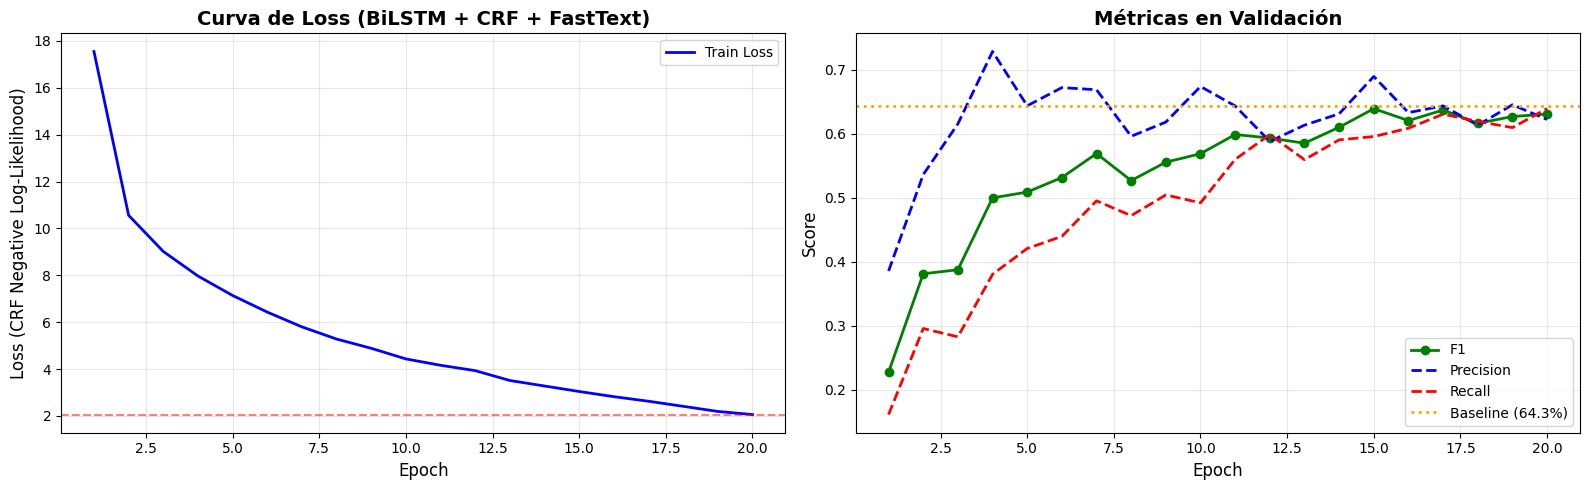

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].axhline(y=history['train_loss'][-1], color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (CRF Negative Log-Likelihood)', fontsize=12)
axes[0].set_title('Curva de Loss (BiLSTM + CRF + FastText)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Métricas
axes[1].plot(epochs, history['valid_f1'], 'g-', label='F1', linewidth=2, marker='o')
axes[1].plot(epochs, history['valid_precision'], 'b--', label='Precision', linewidth=2)
axes[1].plot(epochs, history['valid_recall'], 'r--', label='Recall', linewidth=2)
axes[1].axhline(y=0.643, color='orange', linestyle=':', linewidth=2, label='Baseline (64.3%)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Métricas en Validación', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bilstm_crf_fasttext_curves.png', dpi=300, bbox_inches='tight')
print('✅ Gráficos guardados')
plt.show()

## 13. Guardar Resultados

In [56]:
results = {
    'model': 'BiLSTM + CRF + FastText',
    'dataset': 'CoNLL-2002 Spanish NER',
    'baseline': 0.643,
    'config': CONFIG,
    'embeddings': {
        'type': 'FastText (fasttext-wiki-news-subwords-300)',
        'dimension': 300,
        'coverage': f'{coverage:.2f}%',
        'frozen': CONFIG['freeze_embeddings']
    },
    'vocabulary': {
        'vocab_size': len(word2idx),
        'num_tags': len(tag2idx),
        'entity_types': sorted([t for t in tag2idx.keys() if t.startswith('B-')])
    },
    'training': {
        'best_epoch': checkpoint['epoch'] + 1,
        'best_val_f1': float(checkpoint['best_f1']),
        'total_epochs': len(history['train_loss']),
        'training_time_minutes': training_time / 60,
        'total_params': total_params,
        'trainable_params': trainable_params
    },
    'test_metrics': {
        'f1': float(test_f1),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'improvement_vs_baseline': float((test_f1 - 0.643) * 100)
    },
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'valid_f1': [float(x) for x in history['valid_f1']],
        'valid_precision': [float(x) for x in history['valid_precision']],
        'valid_recall': [float(x) for x in history['valid_recall']]
    }
}

# Guardar JSON
with open(OUTPUT_DIR / 'bilstm_crf_fasttext_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

# Guardar reporte
with open(OUTPUT_DIR / 'bilstm_crf_fasttext_report.txt', 'w', encoding='utf-8') as f:
    f.write('MODELO 1: BiLSTM + CRF + FastText\n')
    f.write('='*70 + '\n\n')
    f.write(f'Dataset: CoNLL-2002 Spanish NER\n')
    f.write(f'Baseline F1: 64.3%\n')
    f.write(f'Parámetros totales: {total_params:,}\n')
    f.write(f'Parámetros entrenables: {trainable_params:,}\n')
    f.write(f'Tiempo de entrenamiento: {training_time/60:.2f} minutos\n\n')
    f.write('TEST SET METRICS:\n')
    f.write(f'  F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)\n')
    f.write(f'  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)\n')
    f.write(f'  Recall: {test_recall:.4f} ({test_recall*100:.2f}%)\n')
    f.write(f'  Mejora vs baseline: {(test_f1 - 0.643)*100:+.2f} puntos\n\n')
    f.write('CLASSIFICATION REPORT:\n')
    f.write('='*70 + '\n')
    f.write(report)

print(f'\n✅ Resultados guardados en /kaggle/working/')
print(f'  - bilstm_crf_fasttext_results.json')
print(f'  - bilstm_crf_fasttext_report.txt')
print(f'  - bilstm_crf_fasttext_curves.png')
print(f'  - bilstm_crf_fasttext_best.pt')
print(f'  - bilstm_crf_fasttext_vocab.json')
print('\n🎉 MODELO 1 COMPLETADO')
print(f'\n📊 Resultado Final: F1 = {test_f1:.4f} ({(test_f1 - 0.643)*100:+.2f} pts vs baseline)')


✅ Resultados guardados en /kaggle/working/
  - bilstm_crf_fasttext_results.json
  - bilstm_crf_fasttext_report.txt
  - bilstm_crf_fasttext_curves.png
  - bilstm_crf_fasttext_best.pt
  - bilstm_crf_fasttext_vocab.json

🎉 MODELO 1 COMPLETADO

📊 Resultado Final: F1 = 0.6421 (-0.09 pts vs baseline)


## 14. Ejemplo de Predicción

In [57]:
def predict_sentence(model, sentence, word2idx, idx2tag, unk_idx=1):
    model.eval()
    words = sentence.lower().split()
    word_ids = [word2idx.get(w, unk_idx) for w in words]
    
    word_ids_tensor = torch.tensor([word_ids], dtype=torch.long).to(device)
    mask = torch.ones((1, len(word_ids)), dtype=torch.bool).to(device)
    
    with torch.no_grad():
        predictions = model(word_ids_tensor, mask=mask)
    
    pred_tags = [idx2tag[idx] for idx in predictions[0][:len(words)]]
    return list(zip(words, pred_tags))

# Ejemplos
test_sentences = [
    "Juan García vive en Madrid y trabaja en Google",
    "El presidente de México visitó Barcelona",
    "María estudia en la Universidad de Salamanca"
]

print('Ejemplos de Predicción con CRF (coherencia en secuencias):\n')
for sentence in test_sentences:
    predictions = predict_sentence(model, sentence, word2idx, idx2tag)
    print(f'Oración: "{sentence}"')
    print('Predicciones:')
    for word, tag in predictions:
        if tag not in ['O', '<PAD>']:
            print(f'  {word:20} -> {tag}')
    print()

Ejemplos de Predicción con CRF (coherencia en secuencias):

Oración: "Juan García vive en Madrid y trabaja en Google"
Predicciones:
  juan                 -> B-PER
  garcía               -> I-PER
  madrid               -> B-LOC
  google               -> B-LOC

Oración: "El presidente de México visitó Barcelona"
Predicciones:
  méxico               -> B-ORG
  visitó               -> I-ORG
  barcelona            -> I-ORG

Oración: "María estudia en la Universidad de Salamanca"
Predicciones:
  maría                -> B-PER

